In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression

In [72]:
DATA_PATH=Path("data/star_classification_CLEAN.csv")
df=pd.read_csv(DATA_PATH)
df

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u_g,g_r,r_i,i_z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,...,1.055431e+19,GALAXY,0.000000,9374,57749,438,-0.80827,1.07182,0.59856,0.56979
99995,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,...,8.586351e+18,GALAXY,0.404895,7626,56934,866,0.30490,1.93625,0.69244,0.34233
99996,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,...,3.112008e+18,GALAXY,0.143366,2764,54535,74,1.89919,1.06569,0.51394,0.33813
99997,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,...,7.601080e+18,GALAXY,0.455040,6751,56368,470,3.71282,1.72371,0.84132,0.44772


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   obj_ID       99999 non-null  float64
 1   alpha        99999 non-null  float64
 2   delta        99999 non-null  float64
 3   u            99999 non-null  float64
 4   g            99999 non-null  float64
 5   r            99999 non-null  float64
 6   i            99999 non-null  float64
 7   z            99999 non-null  float64
 8   run_ID       99999 non-null  int64  
 9   rerun_ID     99999 non-null  int64  
 10  cam_col      99999 non-null  int64  
 11  field_ID     99999 non-null  int64  
 12  spec_obj_ID  99999 non-null  float64
 13  class        99999 non-null  object 
 14  redshift     99999 non-null  float64
 15  plate        99999 non-null  int64  
 16  MJD          99999 non-null  int64  
 17  fiber_ID     99999 non-null  int64  
 18  u_g          99999 non-null  float64
 19  g_r 

In [74]:
id_cols=df[['obj_ID','run_ID','rerun_ID','field_ID','spec_obj_ID','fiber_ID','plate','MJD','cam_col','alpha','delta']]

In [75]:
df=df.drop(columns=id_cols,axis=1)

In [76]:
X=df[['redshift','u','g','r','i','z','u_g','g_r','r_i','i_z']]
y=df['class']

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [78]:
#le=LabelEncoder()

In [79]:
#y_train = le.fit_transform(y_train)
#y_test = le.transform(y_test)

### SMOTE

In [80]:
smote = SMOTE(sampling_strategy='auto', random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

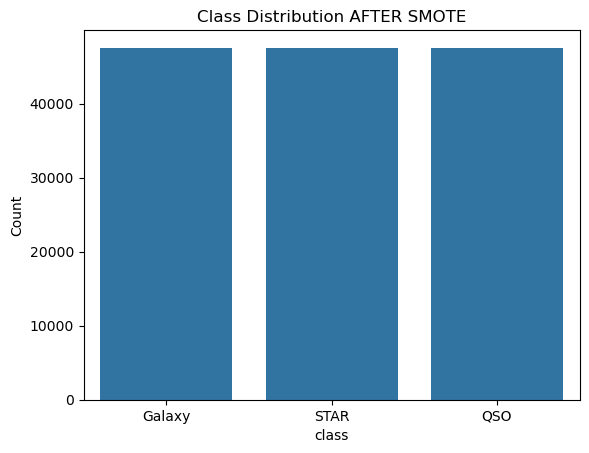

In [81]:
counts_sm = y_train_sm.value_counts()
sns.barplot(x=counts_sm.index, y=counts_sm.values)
plt.xticks([0,1,2], ['Galaxy', 'STAR','QSO'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

### Naive baseline

In [82]:
dummy_clf=DummyClassifier(strategy='most_frequent',random_state=42)
dummy_clf.fit(X_train,y_train)


,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [83]:
y_pred = dummy_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1=(round(f1_score(y_test, y_pred, average='macro'),2))
conf_mat=confusion_matrix(y_test, y_pred)
print(f'Accuracy {accuracy}')
print(f'F1 score {f1}')
print(f'Confusion matrix {conf_mat}')
print(classification_report(y_test,y_pred))

Accuracy 0.59445
F1 score 0.25
Confusion matrix [[11889     0     0]
 [ 3792     0     0]
 [ 4319     0     0]]
              precision    recall  f1-score   support

      GALAXY       0.59      1.00      0.75     11889
         QSO       0.00      0.00      0.00      3792
        STAR       0.00      0.00      0.00      4319

    accuracy                           0.59     20000
   macro avg       0.20      0.33      0.25     20000
weighted avg       0.35      0.59      0.44     20000



c:\Users\andra\miniconda3\envs\python_core\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\andra\miniconda3\envs\python_core\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\andra\miniconda3\envs\python_core\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [84]:
#log_reg_pipeline=Pipeline([('scaler',StandardScaler()),('log_reg',LogisticRegression())])